In [1]:
import pandas as pd

df_merged = pd.read_csv("../Output/christ_bond_merged.csv")

In [2]:
# Filter Christchurch Central (SA2 code 326600)
central = df_merged[df_merged["area_code"] == 326600]

# Calculate median Airbnb price
median_price = central["price"].median()

print("Median Airbnb price:", median_price)

Median Airbnb price: 239.0


In [3]:
df_merged["area_code"] = df_merged["area_code"].astype(str)

central = df_merged[df_merged["area_code"] == "326600"]
median_price = central["price"].median()

print(median_price)

239.0


In [4]:
print(central.shape)   # Number of matching rows
central[["name", "price", "area_code"]].head()

(737, 33)


,name,price,area_code
24,Central Christchurch: Santorini Style 1BR Studio,165.0,326600
30,Style meets comfort 2 Bed CHCH CBD,191.0,326600
41,Luxury CBD 2Bed2Bath With Parking Near Parks,187.0,326600
82,Penthouse Perfection: 2BR Elegance on Worceste...,198.0,326600
92,Central CBD Apartment | Free secure parking | ...,188.0,326600


In [5]:
# Convert weekly rent to nightly rent
df_merged["long_term_night"] = df_merged["Median Rent"] / 7

# Airbnb nightly price - long-term nightly rent
df_merged["price_gap"] = df_merged["price"] - df_merged ["long_term_night"]

# Check it was created
df_merged[["price", "Median Rent", "long_term_night", "price_gap"]].head()

,price,Median Rent,long_term_night,price_gap
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,166.0,723.0,103.285714,62.714286
3,NaN,NaN,NaN,NaN
4,126.0,780.0,111.428571,14.571429


In [6]:
gap_summary = (
    df_merged.groupby("area_code")
      .agg(
          median_gap=("price_gap", "median"),
          mean_gap=("price_gap", "mean"),
          listings=("price_gap", "count")
      )
      .sort_values("median_gap", ascending=False)
)

gap_summary.head(10)

,median_gap,mean_gap,listings
area_code,,,
322800,243.642857,243.023810,6
328800,231.642857,206.642857,8
322600,215.714286,250.974560,73
324200,204.714286,241.047619,3
332700,199.428571,306.520438,339
322100,195.357143,210.124585,86
317400,191.500000,339.620879,26
330500,187.000000,213.275261,41
322500,183.714286,168.393728,41


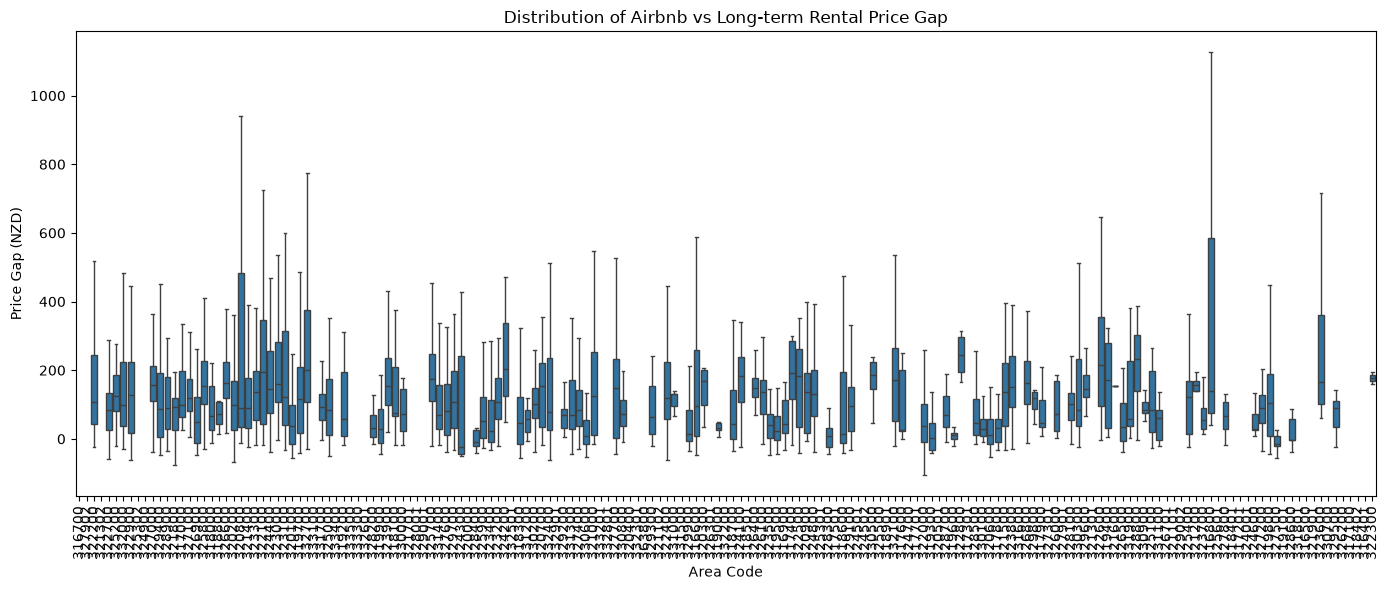

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.boxplot(data=df_merged, x="area_code", y="price_gap", showfliers=False)

plt.xticks(rotation=90)
plt.xlabel("Area Code")
plt.ylabel("Price Gap (NZD)")
plt.title("Distribution of Airbnb vs Long-term Rental Price Gap")
plt.tight_layout()
plt.show()